# HealthConnect – Data Preparation, Feature Engineering & Baseline Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]

## Part 1 – Data Preparation

In [2]:
df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")
df.shape

(5000, 18)

In [3]:
df["appointment_outcome"].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [4]:
df = df[df["appointment_outcome"] != "Cancelled"].copy()
df["no_show"] = (df["appointment_outcome"] == "No-Show").astype(int)
df.shape

(4737, 19)

In [5]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1285
distance_to_clinic_km      86
waiting_time_minutes       58
appointment_outcome         0
no_show                     0
dtype: int64

In [6]:
df["distance_to_clinic_km"] = df["distance_to_clinic_km"].fillna(df["distance_to_clinic_km"].median())
df["reminder_channel"] = df["reminder_channel"].fillna("None")
df.drop(columns=["waiting_time_minutes"], inplace=True)
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum(), df["appointment_id"].duplicated().sum()

(np.int64(0), np.int64(0))

In [8]:
df.drop(columns=["appointment_id", "booking_date", "appointment_date", "age_group", "appointment_outcome"], inplace=True)
df.dtypes

patient_id                   str
gender                       str
age                        int64
appointment_type             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
no_show                    int64
dtype: object

## Part 2 – Data Exploration & Visual Evidence

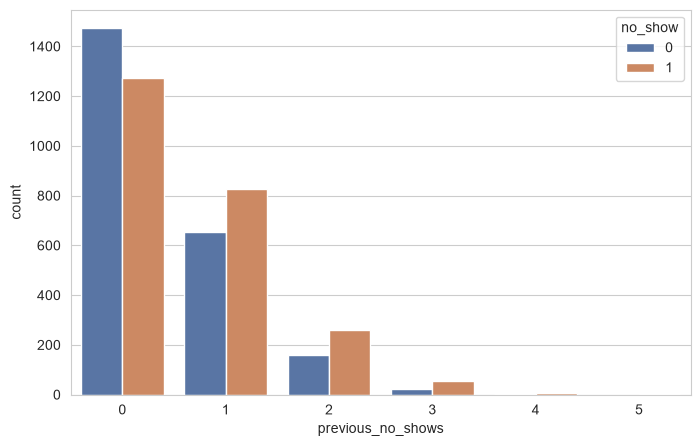

In [9]:
plt.figure()
sns.countplot(data=df, x="previous_no_shows", hue="no_show", palette=COLORS)
plt.savefig("../visuals/01_prevnoshow_vs_target.png", bbox_inches="tight")
plt.show()

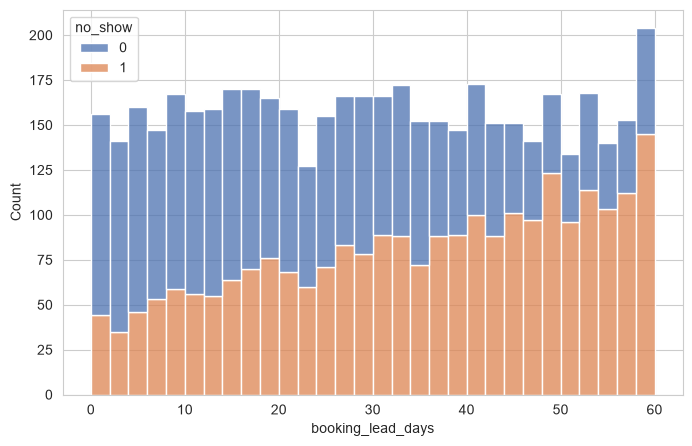

In [10]:
plt.figure()
sns.histplot(data=df, x="booking_lead_days", hue="no_show", multiple="stack", bins=30, palette=COLORS)
plt.savefig("../visuals/02_leaddays_vs_target.png", bbox_inches="tight")
plt.show()

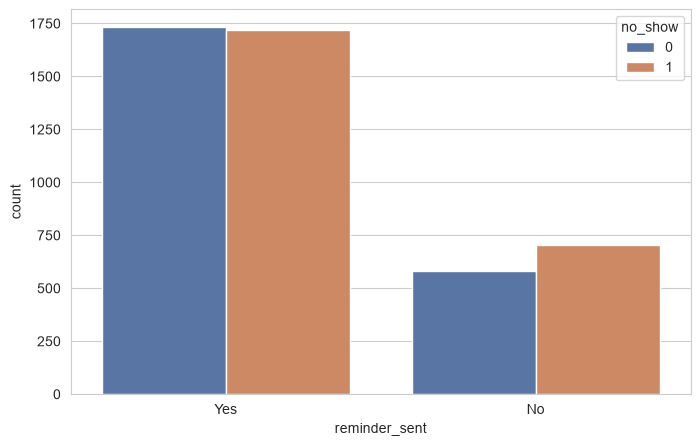

In [11]:
plt.figure()
sns.countplot(data=df, x="reminder_sent", hue="no_show", palette=COLORS)
plt.savefig("../visuals/03_reminder_vs_target.png", bbox_inches="tight")
plt.show()

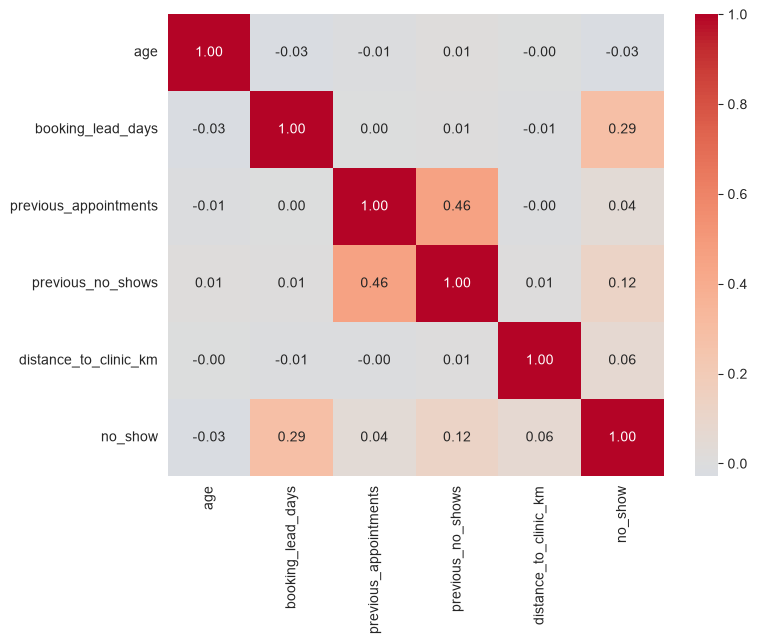

In [12]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.savefig("../visuals/04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Part 3 – Feature Engineering

In [13]:
df["prev_noshow_rate"] = np.where(df["previous_appointments"] > 0,
                                   df["previous_no_shows"] / df["previous_appointments"], 0)
df["has_history"] = (df["previous_appointments"] > 0).astype(int)
df["lead_time_bucket"] = pd.cut(df["booking_lead_days"], bins=[-1, 2, 7, 14, np.inf],
                                 labels=["Same-week", "1-2 weeks", "2-4 weeks", "1+ month"])
df[["prev_noshow_rate", "has_history", "lead_time_bucket"]].head()

,prev_noshow_rate,has_history,lead_time_bucket
0,0.000000,1,2-4 weeks
1,0.000000,1,Same-week
2,0.200000,1,1+ month
3,0.333333,1,1+ month
4,0.333333,1,1+ month


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_27488\1259030182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="no_show", y="prev_noshow_rate", palette=COLORS)


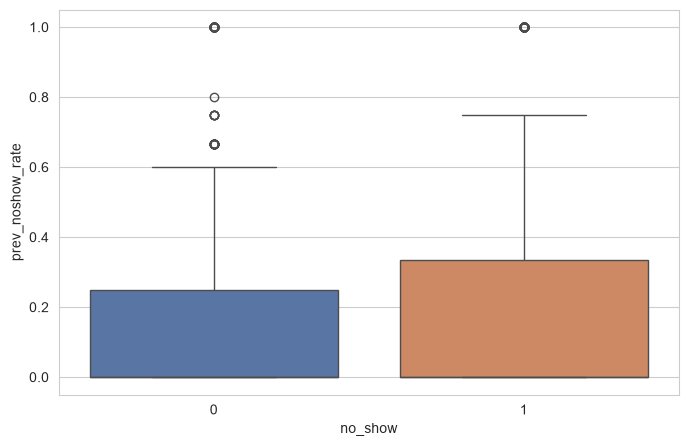

In [14]:
plt.figure()
sns.boxplot(data=df, x="no_show", y="prev_noshow_rate", palette=COLORS)
plt.savefig("../visuals/05_prevnoshowrate_vs_target.png", bbox_inches="tight")
plt.show()

prev_noshow_rate separates the classes more cleanly than the raw count — kept as the primary history feature; previous_no_shows and previous_appointments retained as well since they carry slightly different information (rate vs. volume).

## Part 4 – Train/Test Split

Split at patient level — the same patient_id appears across multiple rows, so a row-level split would leak patient identity into both sets.

In [15]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["patient_id"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
len(train_df), len(test_df), set(train_df["patient_id"]) & set(test_df["patient_id"])


(3771, 966, set())

In [16]:
X_train = train_df.drop(columns=["patient_id", "no_show"])
y_train = train_df["no_show"]
X_test = test_df.drop(columns=["patient_id", "no_show"])
y_test = test_df["no_show"]

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.shape, X_test.shape


((3771, 27), (966, 27))

## Part 5 – Baseline Model

In [17]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Part 6 – Initial Evaluation

In [18]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Accuracy: 0.627
Precision: 0.62
Recall: 0.656
F1: 0.638
ROC-AUC: 0.677


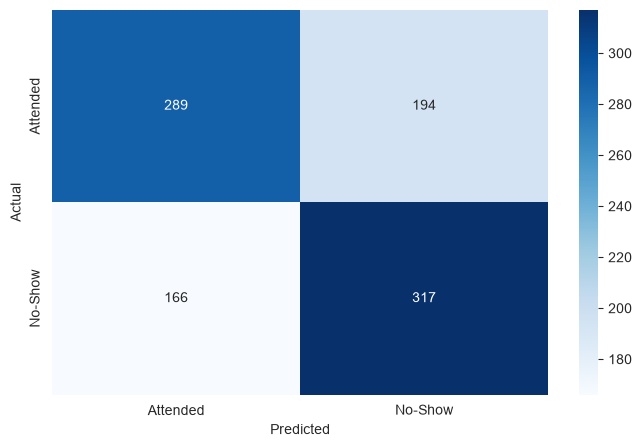

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Attended", "No-Show"], yticklabels=["Attended", "No-Show"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../visuals/06_confusion_matrix.png", bbox_inches="tight")
plt.show()

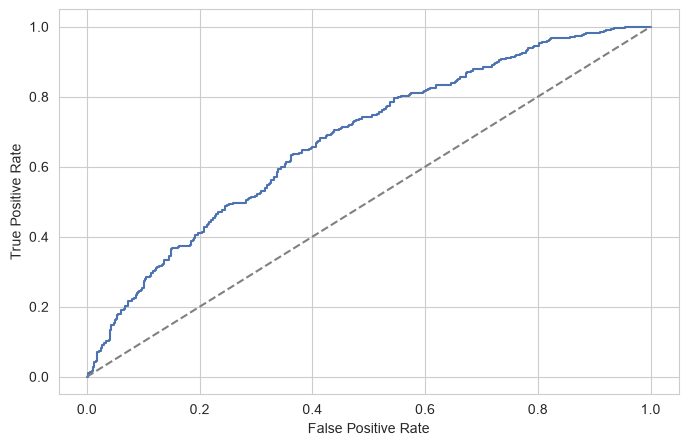

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color=COLORS[0])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.savefig("../visuals/07_roc_curve.png", bbox_inches="tight")
plt.show()

In [21]:
coef_table = pd.DataFrame({"feature": X_train.columns, "coefficient": model.coef_[0]})
coef_table.reindex(coef_table.coefficient.abs().sort_values(ascending=False).index).head(10)

,feature,coefficient
1,booking_lead_days,0.593310
3,previous_no_shows,0.484061
17,appointment_day_Wednesday,0.307412
15,appointment_day_Thursday,0.274616
8,gender_Prefer not to say,-0.258295
14,appointment_day_Sunday,0.228609
12,appointment_day_Monday,0.219409
10,appointment_type_General Consultation,-0.180450
5,prev_noshow_rate,-0.178755
13,appointment_day_Saturday,0.170934
